<a href="https://colab.research.google.com/github/correajoao440-dotcom/fonte-de-informa-o-e-banco-de-dados-/blob/main/An%C3%A1lisededadosdevendasicecream.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("raphaelmanayon/temperature-and-ice-cream-sales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'temperature-and-ice-cream-sales' dataset.
Path to dataset files: /kaggle/input/temperature-and-ice-cream-sales


In [15]:
import pandas as pd
import os

# The actual file name found in the directory
correct_file_name = 'Ice Cream Sales - temperatures.csv'

df = pd.read_csv(os.path.join(path, correct_file_name))
print(df.head(10))

   Temperature  Ice Cream Profits
0           39              13.17
1           40              11.88
2           41              18.82
3           42              18.65
4           43              17.02
5           43              15.88
6           44              19.07
7           44              19.57
8           45              21.62
9           45              22.34


### 1. Definir features (X) e target (y)

In [16]:
X = df[['Temperature']]
y = df['Ice Cream Profits']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (365, 1)
Shape of y: (365,)


### 2. Dividir os dados em conjuntos de treino e teste

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (292, 1)
X_test shape: (73, 1)
y_train shape: (292,)
y_test shape: (73,)


### 3. Treinar o modelo de Regressão Linear

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coefficient (slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"{model.coef_[0]:.2f}x+{model.intercept_: .2f}")

Coefficient (slope): 1.19
Intercept: -33.66
1.19x+-33.66


### 4. Avaliar o modelo e visualizar os resultados

MAE: 1.85
MSE: 5.29
R-squared: 0.98


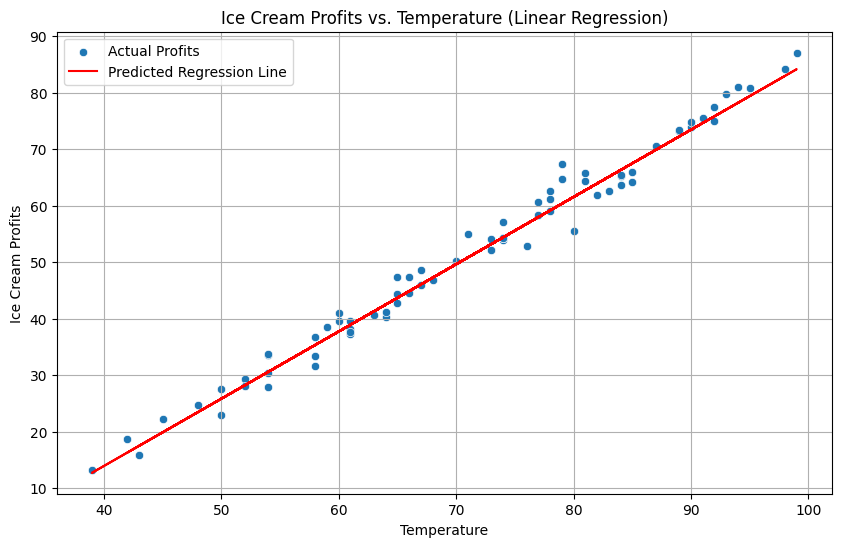

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared: {r2_score(y_test, y_pred):.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Temperature'], y=y_test, label='Actual Profits')
plt.plot(X_test['Temperature'], y_pred, color='red', label='Predicted Regression Line')
plt.title('Ice Cream Profits vs. Temperature (Linear Regression)')
plt.xlabel('Temperature')
plt.ylabel('Ice Cream Profits')
plt.legend()
plt.grid(True)
plt.show()